In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import kagglehub
import os
import osmnx as ox
import geopandas as gpd
from pandas import DataFrame

plt.style.use("seaborn-v0_8")

In [2]:
apartments = pd.read_csv("../data/apartments.csv")
apartments

,price_numeric,municipality,condition,ad_type,rooms,square_m2,equipment,level,heating,price_per_m2,latitude,longitude
0,80.0,Sarajevo - Novo Sarajevo,Renovated,Rent,2.0,62.0,Furnished,16,District Heating,1.290323,43.850305,18.374470
1,100.0,Vogošća,New Build,Rent,2.0,20.0,Furnished,-1,Central (Boiler Room),5.000000,43.901206,18.354117
2,160.0,Trnovo,New Build,Rent,2.0,50.0,Furnished,0,Electric Heating,3.200000,43.714503,18.288786
3,200.0,Sarajevo - Novi Grad,Good Condition,Rent,1.0,30.0,Furnished,1,Central (Boiler Room),6.666667,43.800453,18.246421
4,250.0,Sarajevo - Novo Sarajevo,Good Condition,Rent,2.0,48.0,Unfurnished,0,Electric Heating,5.208333,43.858893,18.399583
...,...,...,...,...,...,...,...,...,...,...,...,...
845,1000000.0,Sarajevo - Centar,Good Condition,Sale,3.0,124.0,Unfurnished,0,Gas Heating,8064.516129,43.853746,18.404423
846,1050000.0,Sarajevo - Novi Grad,New Build,Sale,4.0,146.0,Furnished,8,Central (Boiler Room),7191.780822,43.846929,18.374245
847,1191000.0,Sarajevo - Novo Sarajevo,New Build,Sale,4.0,203.0,Furnished,9,District Heating,5866.995074,43.846926,18.374029
848,1191000.0,Sarajevo - Novi Grad,New Build,Sale,4.0,203.0,Furnished,9,District Heating,5866.995074,43.847530,18.375606


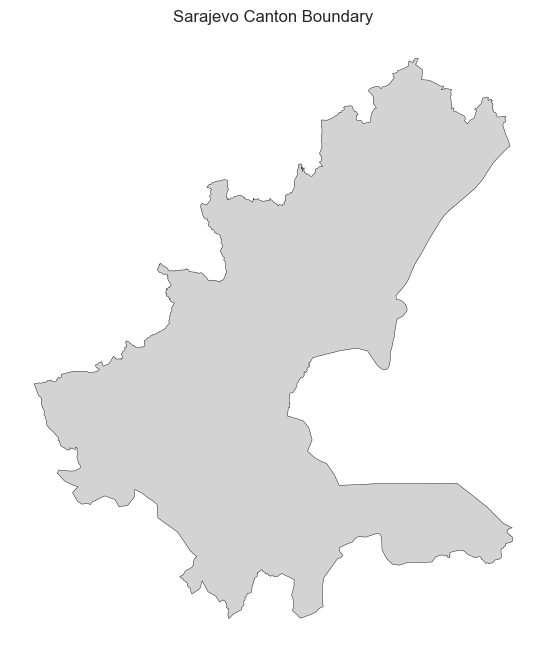

In [3]:
place = "Sarajevo Canton, Bosnia and Herzegovina"

canton = ox.geocode_to_gdf(place).to_crs(epsg=32634)

fig, ax = plt.subplots(figsize=(8, 8))
canton.plot(ax=ax, facecolor="lightgrey", edgecolor="black")
ax.set_title("Sarajevo Canton Boundary")
ax.axis("off")
plt.show()

In [4]:
apartments_gdf = gpd.GeoDataFrame(
    apartments,
    geometry=gpd.points_from_xy(apartments['longitude'], apartments['latitude']),
    crs="EPSG:4326"
).to_crs("EPSG:32634")

apartments_clipped = apartments_gdf.clip(canton)


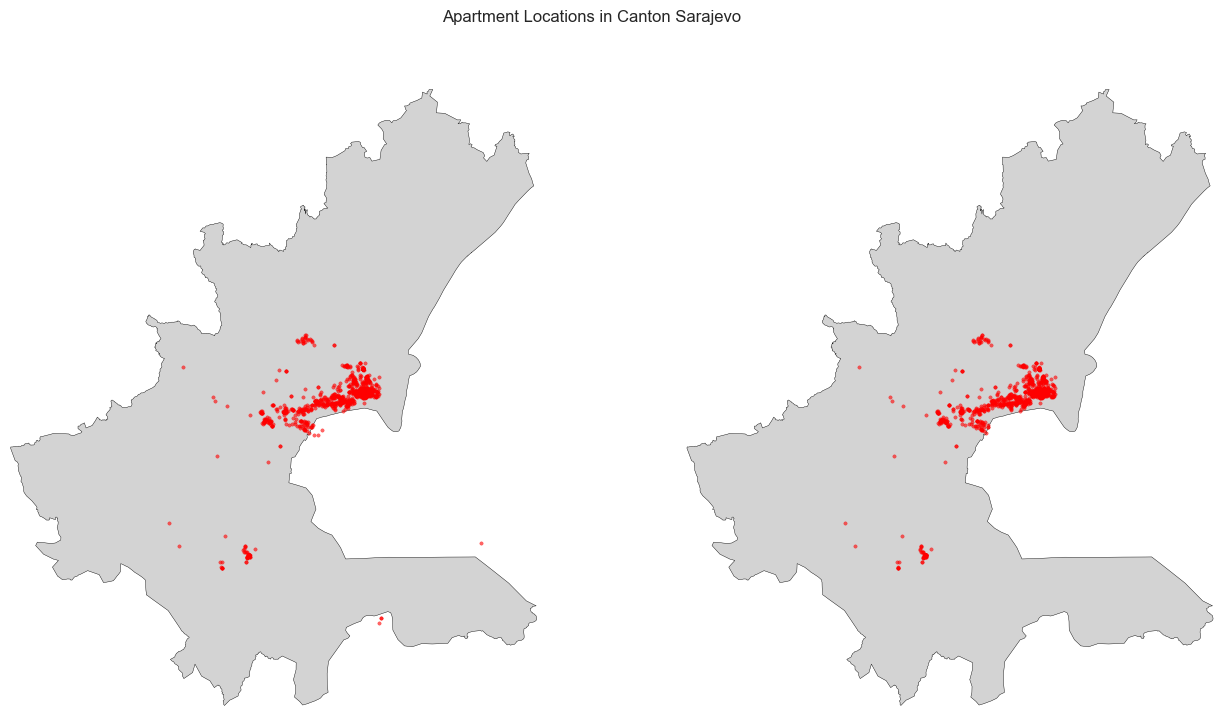

In [5]:
minx, miny, maxx, maxy = canton.total_bounds

plt.subplots(figsize=(16, 8), nrows=1, ncols=2)

ax = plt.subplot(1,2,1)
canton.plot(ax=ax, facecolor="lightgrey", edgecolor="black")
apartments_gdf.plot(
    ax=ax,
    color="red",
    markersize=6,
    alpha=0.6
)
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.axis("off")

ax = plt.subplot(1,2,2)
canton.plot(ax=ax, facecolor="lightgrey", edgecolor="black")
apartments_clipped.plot(
    ax=ax,
    color="red",
    markersize=6,
    alpha=0.6
)

# Force view to canton extent
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.axis("off")

plt.suptitle("Apartment Locations in Canton Sarajevo")
plt.show()

In [6]:
removed_apartments = apartments.loc[
    ~apartments.index.isin(apartments_clipped.index)
]

removed_apartments

,price_numeric,municipality,condition,ad_type,rooms,square_m2,equipment,level,heating,price_per_m2,latitude,longitude
14,400.0,Sarajevo - Novi Grad,New Build,Rent,1.0,35.0,Furnished,3,Central Gas Heating,11.428571,43.820528,18.360500
40,550.0,Sarajevo - Centar,Good Condition,Rent,1.0,38.0,Furnished,4,District Heating,14.473684,44.770647,17.213587
47,550.0,Sarajevo - Novo Sarajevo,Renovated,Rent,2.0,44.0,Furnished,4,District Heating,12.500000,43.825377,18.369031
68,650.0,Sarajevo - Novi Grad,New Build,Rent,3.0,86.0,Semi-Furnished,4,District Heating,7.558140,43.820686,18.365006
107,750.0,Ilidža,New Build,Rent,3.0,57.0,Furnished,6,District Heating,13.157895,43.827596,18.357962
121,800.0,Sarajevo - Novi Grad,New Build,Rent,3.0,64.0,Furnished,4,Central Gas Heating,12.500000,43.829350,18.358322
323,142000.0,Sarajevo - Novi Grad,Good Condition,Sale,2.0,57.3,Furnished,6,Electric Heating,2478.184991,41.194595,19.523676
324,144100.0,Sarajevo - Novi Grad,New Build,Sale,2.0,53.0,Unfurnished,2,Electric Heating,2718.867925,41.232957,19.521073
326,149500.0,Trnovo,New Build,Sale,2.0,30.0,Semi-Furnished,1,Electric Heating,4983.333333,43.665483,18.446512
381,205816.0,Trnovo,Under Construction,Sale,2.0,39.0,Unfurnished,2,Electric Heating,5277.333333,43.661107,18.443999


In [7]:
POI_TAGS = {
    # Healthcare
    "hospital": {"amenity": "hospital"},
    "clinic": {"amenity": "clinic"},
    "pharmacy": {"amenity": "pharmacy"},

    # Education
    "school": {"amenity": "school"},
    "university": {"amenity": "university"},
    "kindergarten": {"amenity": "kindergarten"},

    # Transport
    "bus_stop": {"highway": "bus_stop"},
    "tram_stop": {"railway": "tram_stop"},
    "train_station": {"railway": "station"},
    "parking": {"amenity": "parking"},

    # Environment
    "park": {"leisure": "park"},
    "playground": {"leisure": "playground"},

    # Commerce
    "mall": {"shop": "mall"},
    "supermarket": {"shop": "supermarket"},
    "marketplace": {"amenity": "marketplace"},

    # Urban
    "restaurant": {"amenity": "restaurant"},
    "cafe": {"amenity": "cafe"},
}

In [8]:
poi_data = {}

for name, tags in POI_TAGS.items():
    gdf = ox.features.features_from_place(place, tags).to_crs(epsg=32634)
    # Keep only points (some POIs are polygons)
    gdf = gdf[gdf.geometry.type.isin(["Point", "Polygon"])]

    # Convert polygons to centroids
    gdf["geometry"] = gdf.geometry.centroid

    poi_data[name] = gdf

In [9]:
poi_data['tram_stop']

geometry                 name  \
element id                                                                
node    266195023   POINT (285177.975 4857869.541)                 Stup   
        266195032   POINT (284302.922 4857297.937)         Energoinvest   
        266195034   POINT (283855.576 4856904.537)          Kasindolska   
        266195042   POINT (283641.496 4856603.058)               Ilidža   
        266195056   POINT (284387.177 4857365.607)         Energoinvest   
        266195063   POINT (285186.973 4857867.327)                 Stup   
        266195287   POINT (287777.499 4858394.632)        Alipašin Most   
        266195289   POINT (287260.356 4858302.679)                  RTV   
        266195291    POINT (286728.303 4858209.31)      Alipašino Polje   
        266195292   POINT (286172.225 4858110.863)            Nedžarići   
        266195307   POINT (286280.856 4858126.046)            Nedžarići   
        266195308     POINT (286834.89 4858223.59)      Alipašino Polje   
        266195310   POINT (287345.195 4858313.127)                  RTV   
        266195312   POINT (287807.813 4858395.231)        Alipašin Most   
        266195331    POINT (288765.332 4858576.34)          Čengić Vila   
        266195332   POINT (288295.501 4858483.294)                Otoka   
        266195334   POINT (288404.308 4858497.883)                Otoka   
        266195348   POINT (288956.814 4858616.683)          Čengić Vila   
        266195671   POINT (290366.882 4858956.007)             Pofalići   
        266195676    POINT (289772.688 4858811.93)            Socijalno   
        266195682   POINT (289270.107 4858706.189)          Dolac Malta   
        266195686   POINT (289421.557 4858739.811)          Dolac Malta   
        266195691    POINT (289901.224 4858836.57)            Socijalno   
        266195703   POINT (290489.739 4859003.563)             Pofalići   
        266196009   POINT (291092.162 4859122.217)       Tehnička škola   
        266196011   POINT (290870.851 4859120.788)          Univerzitet   
        266196016   POINT (290858.129 4859115.829)          Univerzitet   
        266196074   POINT (291063.119 4859559.744)  Željeznička stanica   
        267760882   POINT (291225.279 4859112.083)               Muzeji   
        267760965    POINT (291634.35 4859113.168)         Marijin Dvor   
        267761130   POINT (291699.322 4859157.558)         Marijin Dvor   
        1796831382  POINT (288845.889 4858604.176)          Čengić Vila   
        1987831068    POINT (291158.15 4859198.29)       Tehnička škola   
        2007221629  POINT (292130.283 4859168.837)           Skenderija   
        2019899880  POINT (292637.852 4859436.519)                Banka   
        2284451653  POINT (293569.645 4859535.321)           Baščaršija   
        2284451662  POINT (292937.086 4859182.925)             Drvenija   
        2284451673  POINT (293082.993 4859511.032)            Katedrala   
        2284451688  POINT (292662.393 4859177.698)                Pošta   
        2284451696  POINT (293347.701 4859289.173)     Latinska ćuprija   
        2284451702  POINT (293740.324 4859394.493)            Vijećnica   
        2501673799  POINT (292038.229 4859320.054)           Skenderija   
        2504248075  POINT (285657.509 4857993.103)                 Avaz   
        2504248076  POINT (285857.489 4858040.346)                 Avaz   
        2504348091  POINT (283905.138 4856937.394)          Kasindolska   
        3217271029  POINT (292145.559 4859418.655)                 Park   

                   operator public_transport    railway tram wheelchair  \
element id                                                                
node    266195023      GRAS    stop_position  tram_stop  yes        NaN   
        266195032      GRAS    stop_position  tram_stop  yes        NaN   
        266195034      GRAS    stop_position  tram_stop  yes        NaN   
        266195042      GRAS    stop_position  tram_stop  yes      

<Axes: >

<Figure size 1000x800 with 0 Axes>

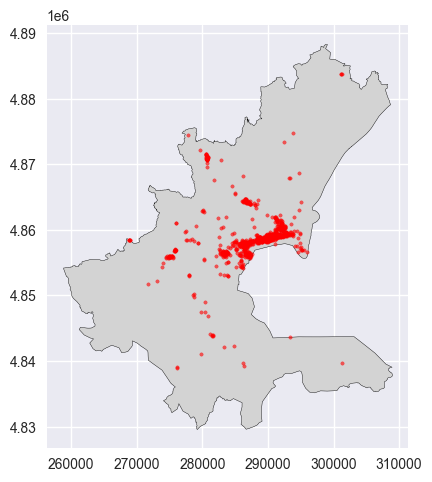

In [21]:
place = "Sarajevo, Bosnia and Herzegovina"
city = ox.geocode_to_gdf(place).to_crs(epsg=32634)

plt.figure(figsize=(10, 8))
ax = canton.plot(facecolor="lightgrey", edgecolor="black")
poi_data['parking'].plot(ax=ax, color="red", markersize=6, alpha=0.6)

In [11]:
from shapely.geometry import Point

def compute_distance(s : pd.Series):
    # Create point in WGS84
    point = Point(s["longitude"], s["latitude"])
    point = gpd.GeoSeries([point], crs="EPSG:4326").to_crs(epsg=32634).iloc[0]

    for poi_name, pois in poi_data.items():
        if pois.empty:
            s[f"closest_{poi_name}_m"] = np.nan
            continue

        idx = pois.sindex.nearest(point, 1)[1][0]
        nearest_geom = pois.geometry.iloc[idx]

        s[f"closest_{poi_name}_m"] = point.distance(nearest_geom)

    return s

apartments = apartments.apply(compute_distance, axis="columns")

In [12]:
apartments

,price_numeric,municipality,condition,ad_type,rooms,square_m2,equipment,level,heating,price_per_m2,...,closest_tram_stop_m,closest_train_station_m,closest_parking_m,closest_park_m,closest_playground_m,closest_mall_m,closest_supermarket_m,closest_marketplace_m,closest_restaurant_m,closest_cafe_m
0,80.0,Sarajevo - Novo Sarajevo,Renovated,Rent,2.0,62.0,Furnished,16,District Heating,1.290323,...,22.523635,2268.941850,102.528115,189.279813,171.672329,178.153115,258.686911,699.392958,306.564487,107.422423
1,100.0,Vogošća,New Build,Rent,2.0,20.0,Furnished,-1,Central (Boiler Room),5.000000,...,5852.796000,3290.043250,327.906390,396.056589,544.868887,880.189027,280.023841,913.563178,434.723961,755.559272
2,160.0,Trnovo,New Build,Rent,2.0,50.0,Furnished,0,Electric Heating,3.200000,...,13029.351303,13784.193020,141.069835,2334.826779,2271.211636,12871.196930,9308.166809,9559.267559,98.131182,191.595278
3,200.0,Sarajevo - Novi Grad,Good Condition,Rent,1.0,30.0,Furnished,1,Central (Boiler Room),6.666667,...,6066.745382,4328.126509,575.817379,3064.030178,2761.287606,5190.145146,4099.007115,5272.969553,2735.716453,3850.725980
4,250.0,Sarajevo - Novo Sarajevo,Good Condition,Rent,2.0,48.0,Unfurnished,0,Electric Heating,5.208333,...,85.304988,181.329171,62.440148,209.084362,190.201896,562.624123,317.926296,975.041615,27.802543,132.096470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
845,1000000.0,Sarajevo - Centar,Good Condition,Sale,3.0,124.0,Unfurnished,0,Gas Heating,8064.516129,...,264.593420,866.137505,130.096058,285.431421,59.182545,318.897701,290.237526,821.438817,229.252303,132.225477
846,1050000.0,Sarajevo - Novi Grad,New Build,Sale,4.0,146.0,Furnished,8,Central (Boiler Room),7191.780822,...,392.100938,2491.437777,51.280361,122.732944,157.309316,444.984170,326.611942,829.797090,233.133205,207.746203
847,1191000.0,Sarajevo - Novo Sarajevo,New Build,Sale,4.0,203.0,Furnished,9,District Heating,5866.995074,...,385.874260,2505.510014,39.566264,125.616267,166.310248,453.140464,309.763957,815.982295,247.693157,202.877680
848,1191000.0,Sarajevo - Novi Grad,New Build,Sale,4.0,203.0,Furnished,9,District Heating,5866.995074,...,343.151690,2363.891765,66.618428,114.301044,81.685657,344.118639,266.804787,825.514846,212.280383,194.116910


<Axes: xlabel='closest_clinic_m', ylabel='Count'>

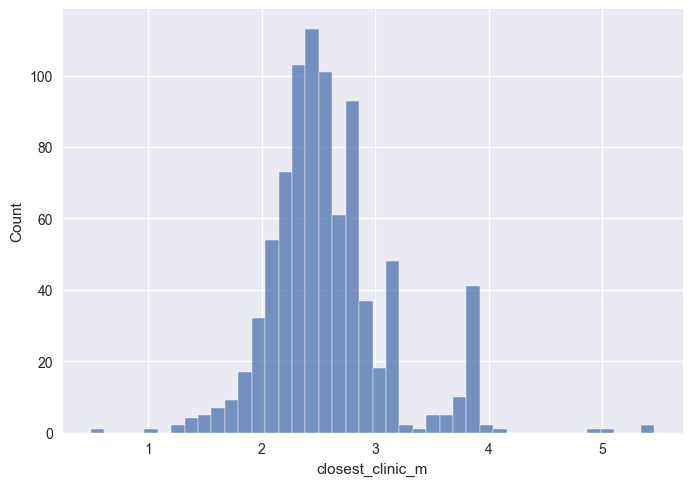

In [34]:
sns.histplot(apartments['closest_clinic_m'].map(np.log10))
#sns.displot(data=apartments['closest_tram_stop_m'].map(np.log), x="closest_tram_stop_m", hue="ad_type")